In [17]:
!pip install pyspark matplotlib seaborn pandas


In [18]:
from google.colab import files
uploaded = files.upload()

# Get filename dynamically
file_name = list(uploaded.keys())[0]
print("Uploaded:", file_name)


Saving Student_performance_data _.csv to Student_performance_data _.csv
Uploaded: Student_performance_data _.csv


In [19]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("StudentPerformancePrediction") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()


In [20]:
df = spark.read.csv(file_name, header=True, inferSchema=True)
print("Total Rows:", df.count())

df.show(5)
df.printSchema()


Total Rows: 2392
+---------+---+------+---------+-----------------+------------------+--------+--------+---------------+---------------+------+-----+------------+------------------+----------+
|StudentID|Age|Gender|Ethnicity|ParentalEducation|   StudyTimeWeekly|Absences|Tutoring|ParentalSupport|Extracurricular|Sports|Music|Volunteering|               GPA|GradeClass|
+---------+---+------+---------+-----------------+------------------+--------+--------+---------------+---------------+------+-----+------------+------------------+----------+
|     1001| 17|     1|        0|                2|19.833722807854713|       7|       1|              2|              0|     0|    1|           0| 2.929195591667681|       2.0|
|     1002| 18|     0|        0|                1| 15.40875605584674|       0|       0|              1|              0|     0|    0|           0| 3.042914833436377|       1.0|
|     1003| 15|     0|        2|                3|  4.21056976881226|      26|       0|              2|

In [21]:
from pyspark.sql.functions import trim

df = df.dropna()          # Remove missing rows
df = df.dropDuplicates()  # Remove duplicates

# Trim all string columns
for colname, dtype in df.dtypes:
    if dtype == "string":
        df = df.withColumn(colname, trim(df[colname]))

print("Cleaned Row Count:", df.count())
df.show(3)


Cleaned Row Count: 2392
+---------+---+------+---------+-----------------+------------------+--------+--------+---------------+---------------+------+-----+------------+------------------+----------+
|StudentID|Age|Gender|Ethnicity|ParentalEducation|   StudyTimeWeekly|Absences|Tutoring|ParentalSupport|Extracurricular|Sports|Music|Volunteering|               GPA|GradeClass|
+---------+---+------+---------+-----------------+------------------+--------+--------+---------------+---------------+------+-----+------------+------------------+----------+
|     1017| 18|     0|        3|                1|10.098656081788002|      14|       0|              2|              1|     1|    0|           0|2.2321752777159762|       3.0|
|     1084| 18|     0|        2|                1|  8.88959955955582|      16|       0|              1|              0|     1|    0|           0|1.4633780357856976|       4.0|
|     1521| 18|     1|        2|                2| 8.288596249340731|      25|       0|         

In [22]:
rdd = df.rdd


In [23]:
gender_count = rdd.map(lambda x: (x["Gender"], 1)) \
                  .reduceByKey(lambda a, b: a + b)

print("Gender Count:", gender_count.collect())


Gender Count: [(0, 1170), (1, 1222)]


In [24]:
gpa_stats = rdd.map(lambda x: ("GPA", (x["GPA"], 1))) \
               .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1]))

avg_gpa = gpa_stats.map(lambda x: x[1][0] / x[1][1]).collect()[0]
print("Average GPA:", avg_gpa)


Average GPA: 1.9061863027265442


In [25]:
df.groupBy("Ethnicity").avg("GPA").show()


+---------+------------------+
|Ethnicity|          avg(GPA)|
+---------+------------------+
|        1|1.9464371639191047|
|        3|1.9476957230037217|
|        2| 1.922125142260431|
|        0|1.8759045956425315|
+---------+------------------+



In [26]:
df.orderBy(df.GPA.desc()).show(5)


+---------+---+------+---------+-----------------+------------------+--------+--------+---------------+---------------+------+-----+------------+---+----------+
|StudentID|Age|Gender|Ethnicity|ParentalEducation|   StudyTimeWeekly|Absences|Tutoring|ParentalSupport|Extracurricular|Sports|Music|Volunteering|GPA|GradeClass|
+---------+---+------+---------+-----------------+------------------+--------+--------+---------------+---------------+------+-----+------------+---+----------+
|     2920| 15|     0|        3|                1|17.442121274931623|       1|       1|              1|              1|     1|    0|           0|4.0|       0.0|
|     3029| 16|     1|        0|                0|18.656924427205983|       0|       1|              4|              1|     0|    0|           1|4.0|       0.0|
|     1443| 15|     0|        0|                2|19.424398237709887|       0|       0|              3|              0|     1|    1|           1|4.0|       0.0|
|     3320| 17|     0|        0|  

In [27]:
df.groupBy("ParentalEducation").avg("StudyTimeWeekly").show()


+-----------------+--------------------+
|ParentalEducation|avg(StudyTimeWeekly)|
+-----------------+--------------------+
|                1|   9.852003764614182|
|                3|   9.419828737102131|
|                4|   9.608854588561885|
|                2|   9.910301437654056|
|                0|   9.613105723163782|
+-----------------+--------------------+



In [28]:
from pyspark.ml.feature import StringIndexer

categorical_cols = ["Gender", "Ethnicity", "ParentalEducation",
                    "Tutoring", "ParentalSupport", "Extracurricular",
                    "Sports", "Music", "Volunteering"]

indexers = [StringIndexer(inputCol=c, outputCol=c+"_index") for c in categorical_cols]


In [29]:
from pyspark.ml.feature import VectorAssembler

feature_cols = ["Age", "StudyTimeWeekly", "Absences", "GPA"] + \
               [c+"_index" for c in categorical_cols]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")


In [30]:
from pyspark.ml.feature import StringIndexer
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline

label_indexer = StringIndexer(inputCol="GradeClass", outputCol="label")

rf = RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=50)

pipeline = Pipeline(stages=indexers + [label_indexer, assembler, rf])


In [31]:
train, test = df.randomSplit([0.8, 0.2], seed=42)


In [32]:
model = pipeline.fit(train)


In [33]:
predictions = model.transform(test)
predictions.select("GradeClass", "prediction", "probability").show(10)


+----------+----------+--------------------+
|GradeClass|prediction|         probability|
+----------+----------+--------------------+
|       4.0|       0.0|[0.91197117560022...|
|       2.0|       2.0|[0.04879255832872...|
|       2.0|       2.0|[0.04604625836580...|
|       4.0|       0.0|[0.89833302947561...|
|       3.0|       1.0|[0.05352408804400...|
|       4.0|       0.0|[0.88223775305305...|
|       4.0|       0.0|[0.91200348654240...|
|       4.0|       0.0|[0.92203435190434...|
|       2.0|       2.0|[0.07437473162405...|
|       2.0|       2.0|[0.03417564465014...|
+----------+----------+--------------------+
only showing top 10 rows



In [34]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(labelCol="label",
                                             predictionCol="prediction",
                                             metricName="accuracy")

accuracy = evaluator.evaluate(predictions)
print("Model Accuracy: {:.2f}%".format(accuracy * 100))


Model Accuracy: 88.57%


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pdf = df.toPandas()


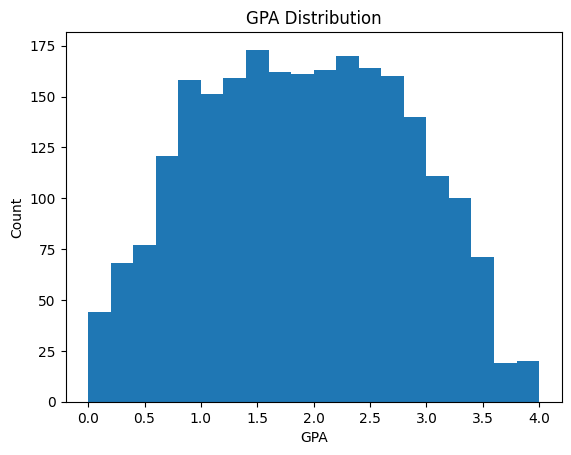

In [36]:
plt.hist(pdf["GPA"], bins=20)
plt.title("GPA Distribution")
plt.xlabel("GPA")
plt.ylabel("Count")
plt.show()


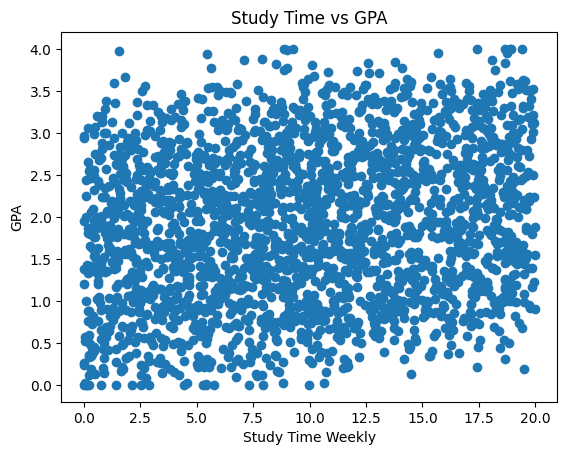

In [37]:
plt.scatter(pdf["StudyTimeWeekly"], pdf["GPA"])
plt.title("Study Time vs GPA")
plt.xlabel("Study Time Weekly")
plt.ylabel("GPA")
plt.show()


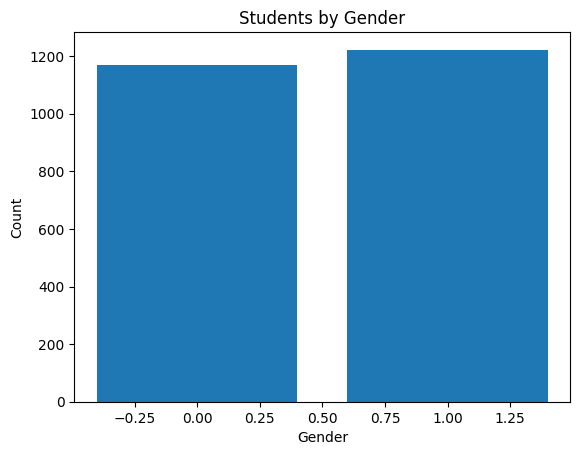

In [38]:
gender_counts = pdf["Gender"].value_counts()

plt.bar(gender_counts.index, gender_counts.values)
plt.title("Students by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


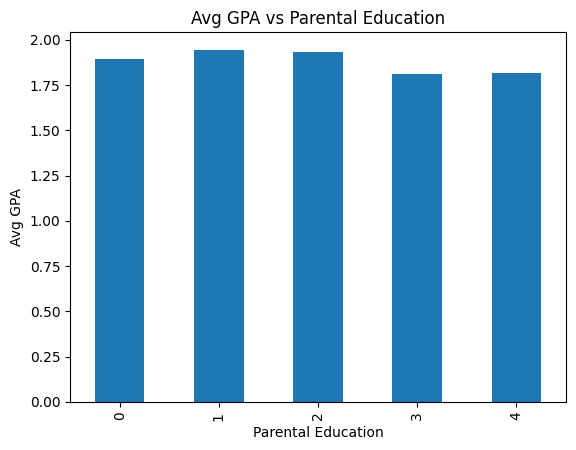

In [39]:
avg_gpa = pdf.groupby("ParentalEducation")["GPA"].mean()

avg_gpa.plot(kind="bar")
plt.title("Avg GPA vs Parental Education")
plt.xlabel("Parental Education")
plt.ylabel("Avg GPA")
plt.show()
